In [2]:
import sys

print("Python version:", sys.version)
print("Python executable:", sys.executable)

Python version: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Python executable: c:\Users\Rohit\anaconda3\envs\cvd-ml\python.exe


In [3]:
import numpy as np
import joblib

# Load preprocessed CVD data
X_train_scaled = np.load("../artifacts/cvd/X_train_scaled.npy")
X_test_scaled = np.load("../artifacts/cvd/X_test_scaled.npy")

y_train = np.load("../artifacts/cvd/y_train.npy")
y_test = np.load("../artifacts/cvd/y_test.npy")

# Load the fitted scaler
scaler = joblib.load("../artifacts/cvd/scaler.pkl")

print("CVD data loaded successfully!")

CVD data loaded successfully!


In [4]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)
print("y_train shape       :", y_train.shape)
print("y_test shape        :", y_test.shape)

print("\nMissing values:")
print("X_train:", np.isnan(X_train_scaled).sum())
print("X_test :", np.isnan(X_test_scaled).sum())
print("y_train:", np.isnan(y_train).sum())
print("y_test :", np.isnan(y_test).sum())

X_train_scaled shape: (54958, 11)
X_test_scaled shape : (13740, 11)
y_train shape       : (54958,)
y_test shape        : (13740,)

Missing values:
X_train: 0
X_test : 0
y_train: 0
y_test : 0


In [5]:
unique, counts = np.unique(y_train, return_counts=True)

print("Training target distribution:")

for label, count in zip(unique, counts):
    percentage = (count / len(y_train)) * 100
    print(f"Class {label}: {count} ({percentage:.2f}%)")

Training target distribution:
Class 0: 27765 (50.52%)
Class 1: 27193 (49.48%)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version: ", tf.__version__)


TensorFlow version:  2.21.0


In [12]:
# Define ANN input layer and first hidden layer

model = keras.Sequential([
    layers.Input(shape=(11,)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.20),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

print("Input layer and first hidden layer created successfully!")

Input layer and first hidden layer created successfully!


In [13]:
model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#Keras needs to know how the model should learn. so we need to compile the model with an optimizer, loss function, and metrics.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7129 - loss: 0.5747 - val_accuracy: 0.7305 - val_loss: 0.5504
Epoch 2/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7262 - loss: 0.5582 - val_accuracy: 0.7299 - val_loss: 0.5541
Epoch 3/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7284 - loss: 0.5556 - val_accuracy: 0.7302 - val_loss: 0.5469
Epoch 4/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7277 - loss: 0.5546 - val_accuracy: 0.7316 - val_loss: 0.5479
Epoch 5/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7301 - loss: 0.5517 - val_accuracy: 0.7316 - val_loss: 0.5479
Epoch 6/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7303 - loss: 0.5508 - val_accuracy: 0.7341 - val_loss: 0.5454
Epoch 7/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7296 - loss: 0.5499 - val_accuracy: 0.7344 - val_loss: 0.5459
Epoch 8/100
1374/1374 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7315 - loss: 0

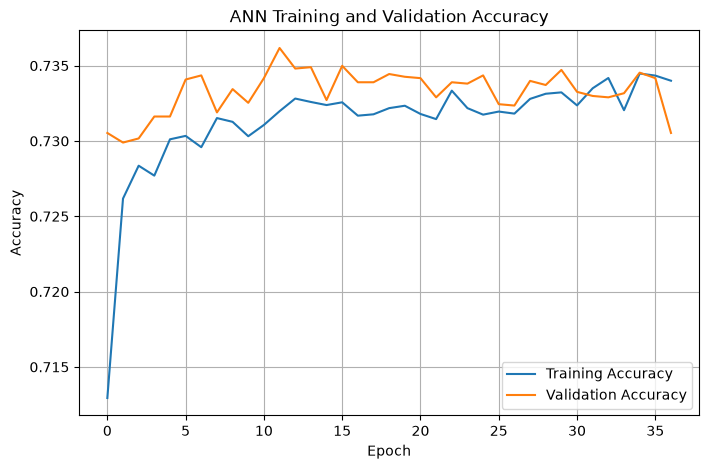

In [16]:
#Step 17 — Plot Training History
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

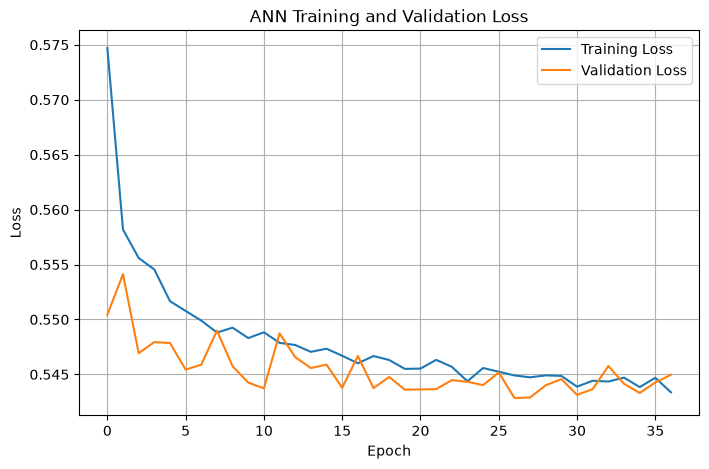

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ANN Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()